2.4.0


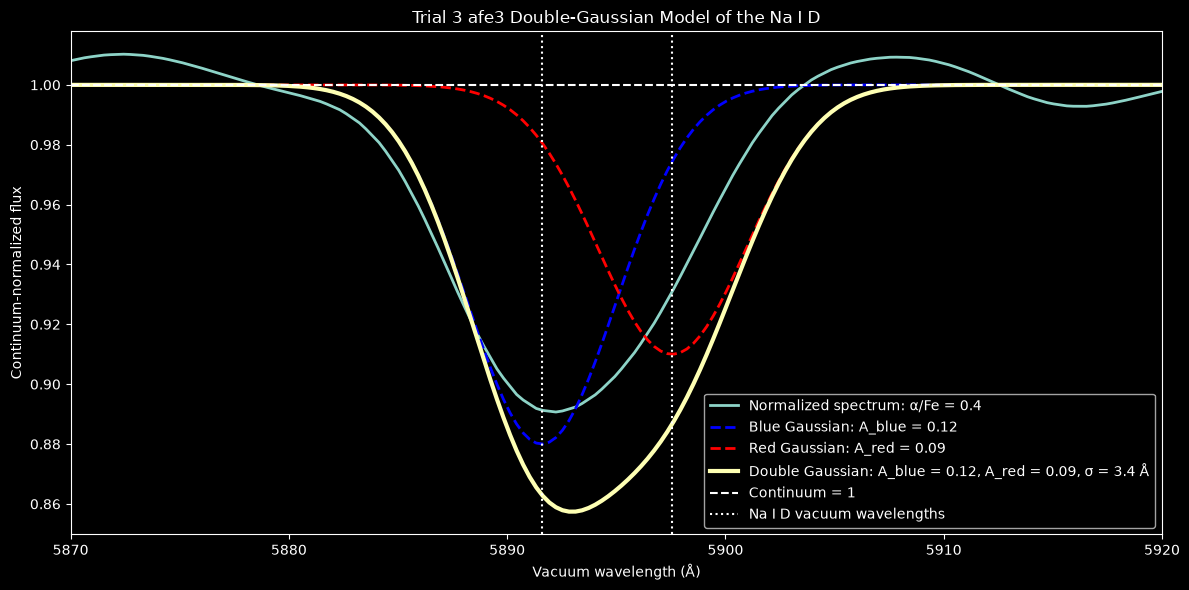

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

import json

specs_fil = "../Data/afe_vary_specs.json"
with open(specs_fil, "rt") as fh:
    specs = json.load(fh)
# Common wavelength array for all of the spectra
wave = specs["wave"]
# read in first spectrum:
afe0 = specs["0"]["afe"]
spec0 = specs["0"]["spec"]

afe1 = specs["1"]["afe"]
spec1 = specs["1"]["spec"]

afe2 = specs["2"]["afe"]
spec2 = specs["2"]["spec"]

afe3 = specs["3"]["afe"]
spec3 = specs["3"]["spec"]

afe4 = specs["4"]["afe"]
spec4 = specs["4"]["spec"]

from numpy.polynomial import Legendre

# Convert the wavelength and spectrum into NumPy arrays
wave_array = np.array(wave)
flux_array = np.array(spec3)

# Defining the Na I D wavwelengths
na_d1 = 5891.583
na_d2 = 5897.558
 # Calculate their midpoint
na_center = (na_d1 + na_d2) / 2

# Defining the full fitting region (+ / - 50 arond the doublet)
fit_min = na_center - 50
fit_max = na_center + 50

# Create a mask (an array of True and False values) (& means both conditions must be True)
region_mask = (
    (wave_array >= fit_min)
    & (wave_array <= fit_max)
)

# Exclude the Na I D absorption region
absorption_mask = (
    (wave_array >= 5885)
    & (wave_array <= 5905)
)

# Create the continuum mask
continuum_mask = region_mask & ~absorption_mask # ~ means "Not", this line is basically saying "Keep wavelengths inside the full fitting region, but exclude wavelengths inside the absorption feature" and this is the most important part because I was specifically told by my mentor that THE ABSORPTION MUST NOT INFLUENCE THE FIT

# Select the data used for the fit, these lines select only the points where continuum_mask is True. Exctract points used in the polynomial fit
fit_wave = wave_array[continuum_mask]
fit_flux = flux_array[continuum_mask]

# Fit second-order Legendre polynomial
continuum_model = Legendre.fit( # fits a Legendre polynomial to the data
    fit_wave, # horizontal-axis data
    fit_flux, # vertical-axis data
    deg = 6 # using a sixth-order polynomial
)

# Evaluate the fitted continuum across the full region
region_wave = wave_array[region_mask] # contains all wavelengths in the full +/- 50 region
region_flux = flux_array[region_mask] # contains the corresponding original spectrum

continuum_flux = continuum_model(region_wave) # evaluates the fitted polynomial at every wavelength, including across the absorption feature that was excluded from the fitting process

import specutils
print(specutils.__version__)

import astropy.units as u
from specutils.utils.wcs_utils import air_to_vac
from numpy.polynomial import Legendre

# Convert the original wavelength list into a NumPy array
wave_air = np.array(wave) # This converts my original JSON wavelength list into a NumPy array

# Attach angstrom units to the air-wavelength array (* u.AA)
wave_air_quantity = wave_air * u.AA

# Convert the wavelengths from air to vacuum
wave_vac_quantity = air_to_vac(wave_air_quantity) # air-to-vacuum conversion for every wavelength in the array

# Remove the Astropy unit object while keeping the values in angstroms
wave_array = wave_vac_quantity.to_value(u.AA)

# Convert the first spectrum into a Numpy array
flux_array = np.array(spec3) # Wavelength convention changes, but the values do not. Therefore only convert the x-axis array, NOT the spectrum itself

# Checking region around sodium
nearest_index = np.argmin(np.abs(wave_air - 5890)) # Calculates how far every wavelength is from 5890. np.argmin() returns the position of the smallest difference, meaning the wavelength closest to 5890

# Define the vacuum wavelengths of the Na I D doublet
na_d1 = 5891.583
na_d2 = 5897.558

# Calculate the midpoint of the doublet
na_center = (na_d1 + na_d2) / 2

# Define the fitting region as plus or minus 50 angstroms
fit_min = na_center - 50
fit_max = na_center + 50

# Divide the original spectrum by the fitted continuum
normalized_flux = region_flux / continuum_flux

# Create a mask (an array of True and False values) (& means both conditions must be True)
region_mask = (
    (wave_array >= fit_min)
    & (wave_array <= fit_max)
)

# Exclude the Na I D absorption region
absorption_mask = (
    (wave_array >= 5885)
    & (wave_array <= 5905)
)

# Create the continuum mask
continuum_mask = region_mask & ~absorption_mask # ~ means "Not", this line is basically saying "Keep wavelengths inside the full fitting region, but exclude wavelengths inside the absorption feature" and this is the most important part because I was specifically told by my mentor that THE ABSORPTION MUST NOT INFLUENCE THE FIT

# Select the data used for the fit, these lines select only the points where continuum_mask is True. Exctract points used in the polynomial fit
fit_wave = wave_array[continuum_mask]
fit_flux = flux_array[continuum_mask]

# Fit Legendre polynomial (1-6 orders)
continuum_model = Legendre.fit( # fits a Legendre polynomial to the data
    fit_wave, # horizontal-axis data
    fit_flux, # vertical-axis data
    deg = 6 # using a 1-6 order polynomial (whatever number I want)
)

# Evaluate the fitted continuum across the full region
region_wave = wave_array[region_mask] # contains all wavelengths in the full +/- 50 region
region_flux = flux_array[region_mask] # contains the corresponding original spectrum

continuum_flux = continuum_model(region_wave) # evaluates the fitted polynomial at every wavelength, including across the absorption feature that was excluded from the fitting process

# Trial values for the blue Na I D line
amplitude_blue = 0.12 # This controls the depth of the blue line. At its center, the model is approx. 1 - 0.12 = 0.88 so the line removes 12% of the continuum light before overlap with the red component.

sigma_sys = 4.0 # This controls the width of the line in angstroms. A larger sigma_sys gives a broader dip. A smaller value gives a narrower dip.

# Fixed vacuum wavelength of the blue line
lambda_blue = 5891.583 # Fixes the center of the blue memeber of the Na I D doublet

# Build the blue Gaussian absorption component
blue_component = 1 - amplitude_blue * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys ** 2)
)

# Creating the red absorption line

# Trial value for the red Na I D line
amplitude_red = 0.08 # controls the red line's depth

# Fixed vacuum wavelength of the red line
lambda_red = 5897.588 # fixes its center

# Build the red Gaussian absorprtion component
red_component = 1 - amplitude_red * np.exp(
    -((region_wave - lambda_red) ** 2) / (2 * sigma_sys ** 2)
)

double_gaussian = blue_component * red_component

# Showing the blue and red Gaussian components

plt.style.use("dark_background") # Changes figure background color from white to black
# Trials 1-4 Double-Gaussian model
# Trial 1-4 parameter values
amplitude_blue_trials = 0.12 # How deep the blue line is
amplitude_red_trials = 0.09 # How deep the red line is
sigma_sys_trials = 3.4 # How deep the red line is

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trials= 1 - amplitude_blue_trials * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trials ** 2)
)

# Create the red Gaussian absorption component
red_component_trials = 1 - amplitude_red_trials * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trials ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian = (
    blue_component_trials * red_component_trials
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe3:.1f}"
)

# Adding the blue Gaussian component
plt.plot(
    region_wave,
    blue_component_trials,
    linewidth = 2,
    linestyle = "--",
    color = "blue",
    label = f"Blue Gaussian: A_blue = {amplitude_blue_trials:.2f}"
)

# Adding the red Gaussian component
plt.plot(
    region_wave,
    red_component_trials,
    linewidth = 2,
    linestyle = "--",
    color = "red",
    label = f"Red Gaussian: A_red = {amplitude_red_trials:.2f}"
)

# Overplot the Trials Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trials:.2f}, "
        f"A_red = {amplitude_red_trials:.2f}, "
        f"σ = {sigma_sys_trials:.1f} Å"
    )
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 3 afe3 Double-Gaussian Model of the Na I D")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Trial 3 afe3 Na D Double Gaussian with Blue and Red Components.png",
    dpi = 300
)

plt.show()

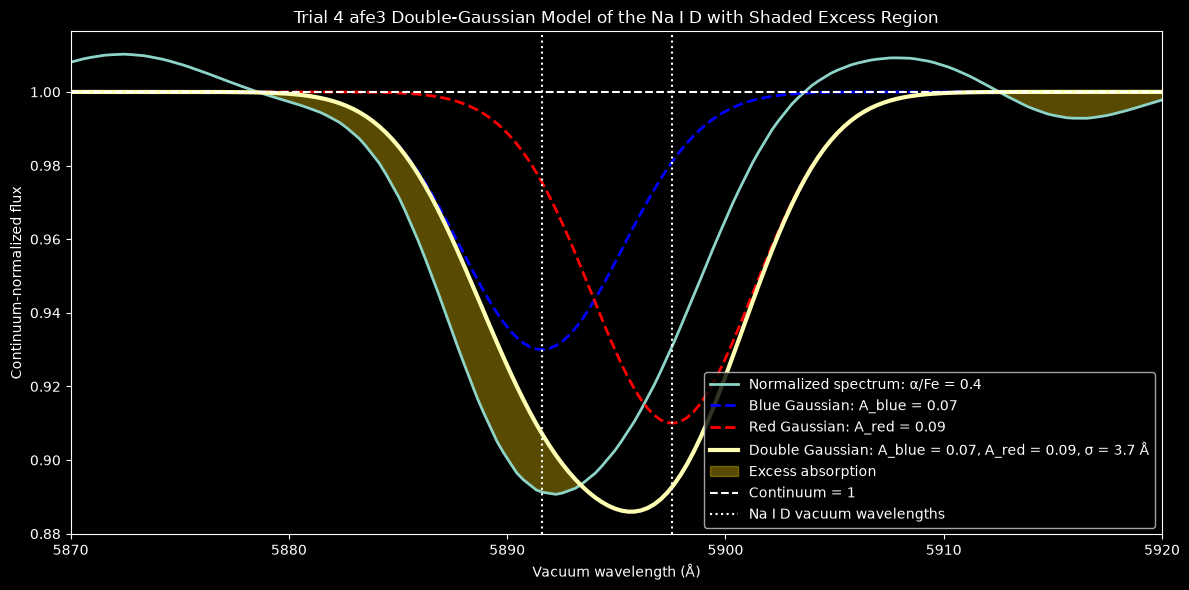

In [5]:
# Shading Excess Region of best trial figure

# Trials 2-4

# Showing the blue and red Gaussian components

plt.style.use("dark_background") # Changes figure background color from white to black
# Trials 2-4 Double-Gaussian model
# Trial 2-4 parameter values
amplitude_blue_trials = 0.07 # How deep the blue line is
amplitude_red_trials = 0.09 # How deep the red line is
sigma_sys_trials = 3.7 # How wide both lines are

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trials= 1 - amplitude_blue_trials * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trials ** 2)
)

# Create the red Gaussian absorption component
red_component_trials = 1 - amplitude_red_trials * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trials ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian = (
    blue_component_trials * red_component_trials
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe3:.1f}"
)

# Adding the blue Gaussian component
plt.plot(
    region_wave,
    blue_component_trials,
    linewidth = 2,
    linestyle = "--",
    color = "blue",
    label = f"Blue Gaussian: A_blue = {amplitude_blue_trials:.2f}"
)

# Adding the red Gaussian component
plt.plot(
    region_wave,
    red_component_trials,
    linewidth = 2,
    linestyle = "--",
    color = "red",
    label = f"Red Gaussian: A_red = {amplitude_red_trials:.2f}"
)

# Overplot the Trials Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trials:.2f}, "
        f"A_red = {amplitude_red_trials:.2f}, "
        f"σ = {sigma_sys_trials:.1f} Å"
    )
)

# Shading the region
plt.fill_between( # colors area between two lines
    region_wave, # x-axis to shade
    normalized_flux, # first boundary of the shaded region
    double_gaussian, # second boundary of the shaded region
    where = (normalized_flux < double_gaussian), # normalized_flux = observed spectrum. double_gaussian = fitted stellar model, shade the observed spectrum that's less than the fitted stellar model
    interpolate = True, # Matplotlib estimates exactly where the two curves intersect, the shading ends smoothly at that estiamted crossing
    color = "gold",
    alpha = 0.35, # Trasnparency of shaded color
    label = "Excess absorption"
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 4 afe3 Double-Gaussian Model of the Na I D with Shaded Excess Region")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Trial 4 afe3 Na D Double Gaussian with Blue and Red Components and Shaded Excess Region.png",
    dpi = 300
)

plt.show()

In [6]:
from scipy.optimize import curve_fit

In [7]:
def func(x, A_blue, sig_blue, A_red, sig_red): # Automatically finds parameters
    # Create the blue Gaussian absorption component
    lambda_blue = 5891.583
    lambda_red = 5897.558
    blue_component = 1 - A_blue * np.exp(
        -((x - lambda_blue) ** 2) / (2 * sig_blue ** 2)
    )
    # Create the red Gaussian absorption component
    red_component = 1 - A_red * np.exp(
        -((x - lambda_red) **2) / (2 * sig_red ** 2)
    )

    # Multiply the two components to produce Equation C1
    double_gaussian = blue_component * red_component

    return double_gaussian


In [8]:
popt, pcov = curve_fit(func, region_wave, normalized_flux, p0 = [0.183, 3.6, 0.08, 3.6]) # parameter guesses
# popt means optimized parameters
# pcov means covariance matrix, it contains informartion about the estimated uncertainties and relationships among the fitted parameters

In [9]:
print(popt)

[0.10803881 4.04122324 0.03540331 2.50962036]


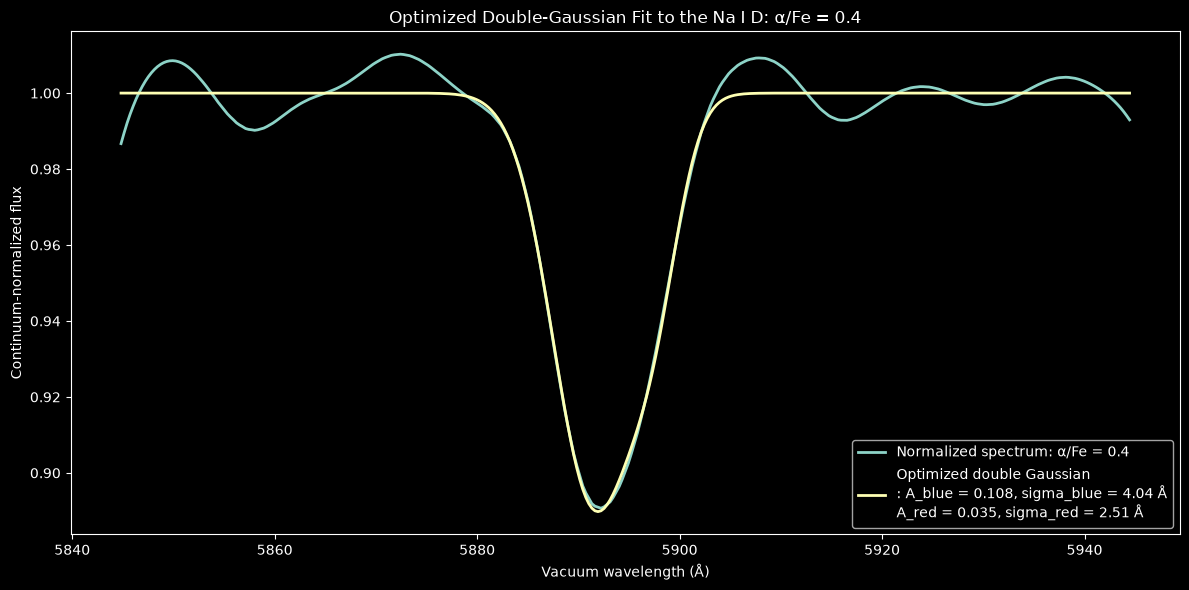

In [10]:
# create a new plot with new paramaters
plt.style.use("dark_background")
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave, # x values
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe3:.1f}"
)
# create the optimized fit
gauss_fit = func(region_wave, popt[0], popt[1], popt[2], popt[3]) # y values I want to plot

# plot the optimized double-Gaussian fit
plt.plot( # plots the yellow fitted model
    region_wave,
    gauss_fit,
    linewidth = 2,
    label = (f"Optimized double Gaussian\n: "
            f"A_blue = {popt[0]:.3f}, sigma_blue = {popt[1]:.2f} Å\n"
            f"A_red = {popt[2]:.3f}, sigma_red = {popt[3]:.2f} Å"
    )
)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")

plt.title(
    f"Optimized Double-Gaussian Fit to the Na I D: ⍺/Fe = {afe3:.1f}"
)

plt.legend(loc = "lower right")

plt.tight_layout()

plt.savefig(
    "../Figures/Optimized Double Gaussian Fit afe3.png",
    dpi = 300
)

plt.show()

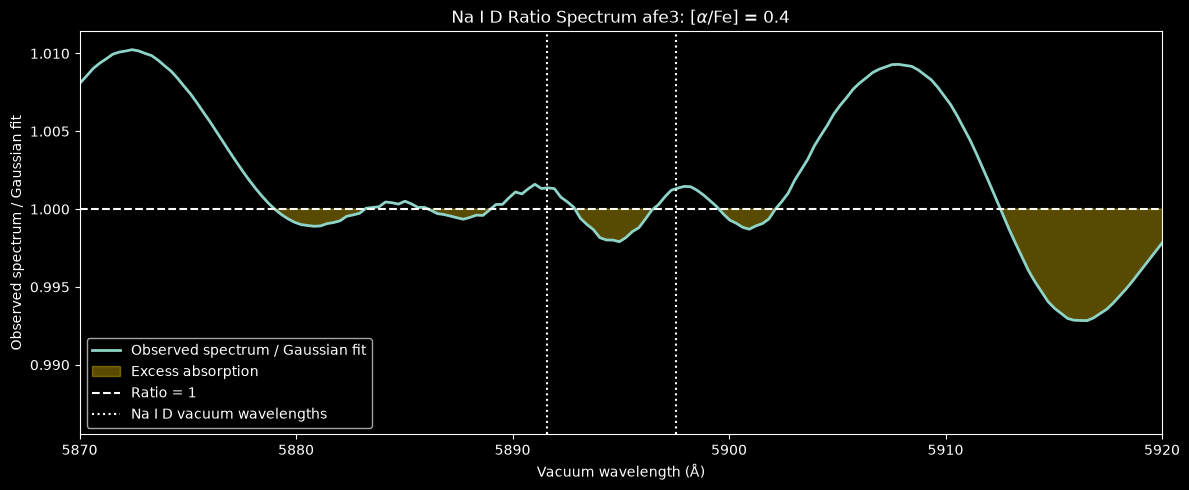

In [12]:
# ratio

# divide the observed normalized spectrum by the optimized Gaussian fit
ratio = normalized_flux / gauss_fit # creates a brand new array called ratio

# create a new figure for the ratio spectrum
plt.style.use("dark_background")
plt.figure(figsize = (12, 5))

# plot the ratio spectrum
plt.plot(
    region_wave, # region_wave is x-axis, contains vacuum wavelength
    ratio, # y-axis, contains observed normalized flux / optimized Gaussian fit
    linewidth = 2,
    label = "Observed spectrum / Gaussian fit"
)

# shade where the ratio is below 1
plt.fill_between( # (x, y1, y2)
    region_wave, # (x-values (x))
    ratio, # first y-curve (y1))
    1, # second y-curve (y2))
    where = (ratio < 1),
    interpolate = True,
    color = "gold",
    alpha = 0.35,
    label = "Excess absorption"
)

# Draw the reference level where the data and model match
plt.axhline( # horizontal = y
    1, # place the line at y = 1
    linestyle = "--",
    linewidth = 1.5,
    label = "Ratio = 1"
)

# Mark the blue Na I D wavelength
plt.axvline( # vertical = x
    5891.583, # x-axis
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Mark the red Na I D wavelength
plt.axvline( # vertical = x
    5897.558, # x-axis
    linestyle = ":",
    linewidth = 1.5,
)

# zooms the x-axis
plt.xlim(5870, 5920)

# Labels the axes
plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Observed spectrum / Gaussian fit")

plt.title(
    fr"Na I D Ratio Spectrum afe3: $[\alpha/\mathrm{{Fe}}]$ = {afe3:.1f}"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../Figures/Na I D Ratio Spectrum afe3.png",
    dpi = 300
)

plt.show()